In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv

# Tesla EV Deliveries and Production Analysis (2015-2025)

This project analyzes Tesla's deliveries, production, pricing, battery capacity, and regional performance using data from 2015 to 2025.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv')

In [3]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
df.shape


(2640, 12)

In [5]:
df.columns


Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [7]:
df.isnull().sum()


Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [8]:
df.duplicated().sum()


np.int64(0)

In [9]:
df = df.drop_duplicates()


In [10]:
df.describe()


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [11]:
model_sales = df.groupby("Model")["Estimated_Deliveries"].sum()
model_sales.sort_values(ascending=False)

Model
Model S       5380385
Model 3       5321919
Model Y       5225284
Model X       5157240
Cybertruck    5109779
Name: Estimated_Deliveries, dtype: int64

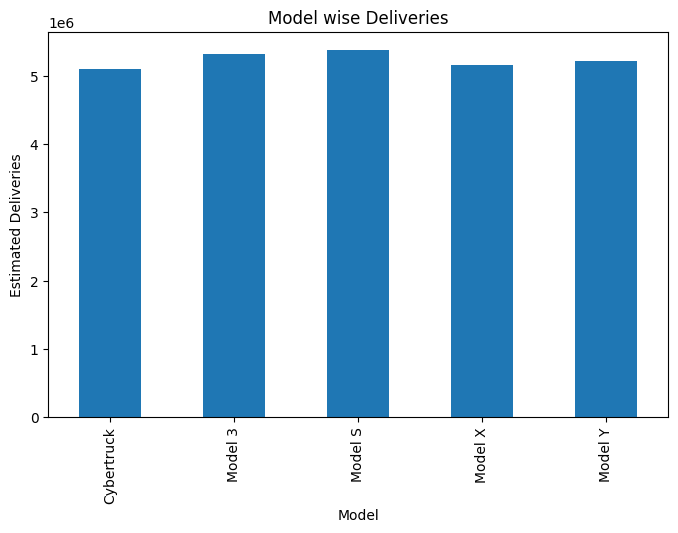

In [12]:
plt.figure(figsize=(8,5))
model_sales.plot(kind='bar')

plt.title("Model wise Deliveries")
plt.xlabel("Model")
plt.ylabel("Estimated Deliveries")

plt.show()

# Insight(Model)

From the graph, we can see that Model S has the highest deliveries and Cybertruck has the lowest. The delivery numbers of all models are quite close to each other.

In [13]:
region_sales = df.groupby("Region")["Estimated_Deliveries"].sum()
region_sales.sort_values(ascending=False)

Region
Middle East      6698045
Asia             6539935
Europe           6494035
North America    6462592
Name: Estimated_Deliveries, dtype: int64

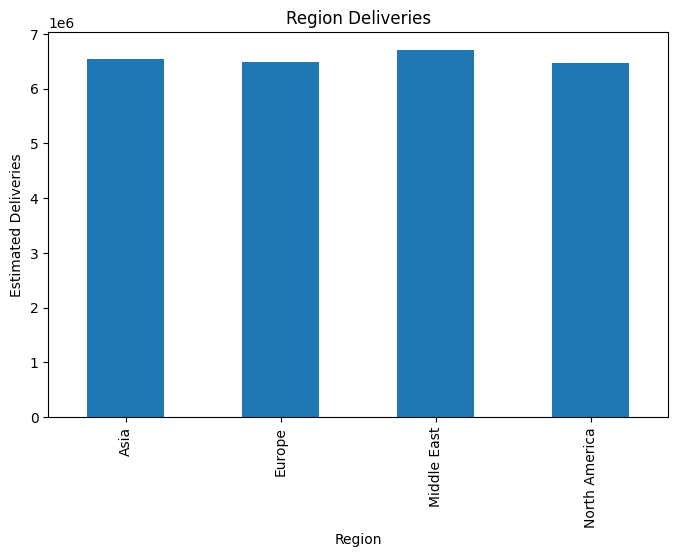

In [14]:
plt.figure(figsize=(8,5))
region_sales.plot(kind='bar')
plt.title("Region Deliveries")
plt.xlabel("Region")
plt.ylabel("Estimated Deliveries")

plt.show()

# Insight(Region)

Middle East has the highest number of deliveries in the dataset. North America has the lowest deliveries. The delivery numbers across all regions are almost close to each other.

In [15]:
yearly_sales = df.groupby("Year")["Estimated_Deliveries"].sum()
yearly_sales.sort_values(ascending=False)

Year
2022    2434220
2016    2434081
2018    2423104
2024    2406899
2019    2404230
2023    2382375
2015    2375267
2025    2368462
2017    2350517
2021    2335116
2020    2280336
Name: Estimated_Deliveries, dtype: int64

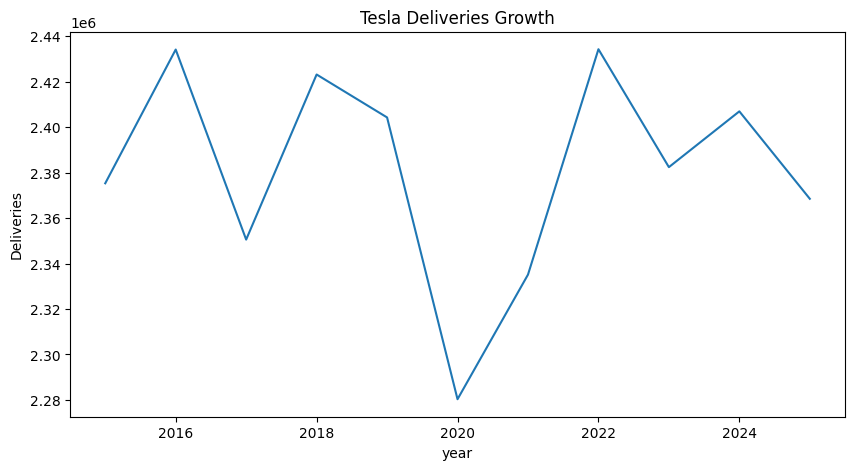

In [16]:
plt.figure(figsize=(10,5))

plt.plot(yearly_sales.index, yearly_sales.values)
plt.title("Tesla Deliveries Growth")
plt.xlabel("year")
plt.ylabel("Deliveries")

plt.show()

# Insight

This graph shows how Tesla deliveries changed over the years and helps identify growth trends.

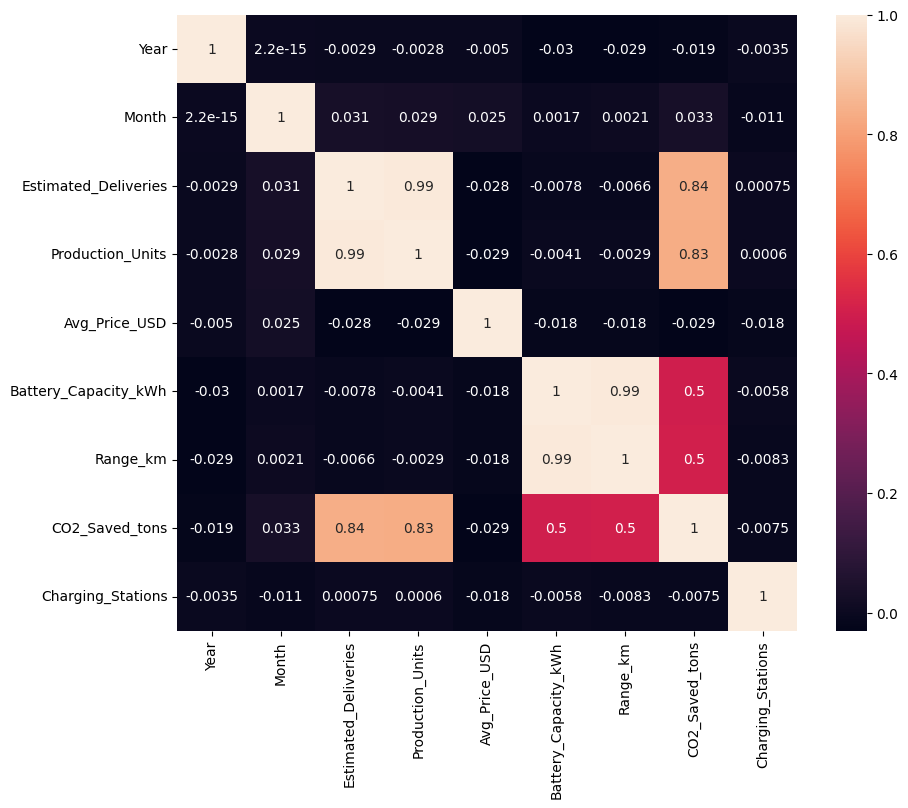

In [17]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True)

plt.show()

# Insight

This heatmap shows how different numerical columns are related to each other.

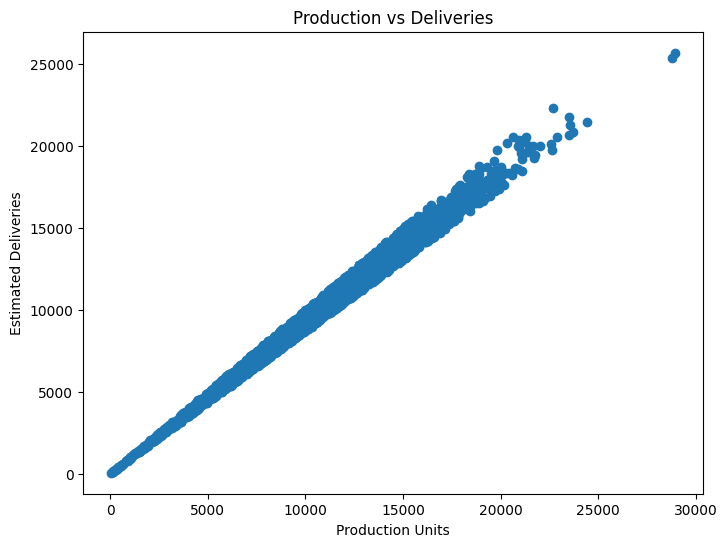

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(df["Production_Units"], df["Estimated_Deliveries"])
plt.title("Production vs Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")

plt.show()

# Insight

Insight
As production increases, Deliveries also tend to increases.

In [19]:
battery_data = df.groupby("Battery_Capacity_kWh")["Estimated_Deliveries"].mean()

battery_data.sort_values(ascending=False)

Battery_Capacity_kWh
100    10058.243513
60     10003.232601
82      9952.567468
120     9802.618596
75      9796.843810
Name: Estimated_Deliveries, dtype: float64

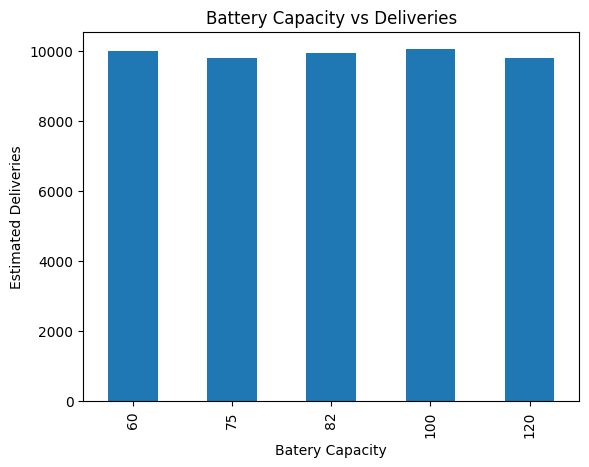

In [20]:
battery_data.plot(kind='bar')

plt.title("Battery Capacity vs Deliveries")
plt.xlabel("Batery Capacity")
plt.ylabel("Estimated Deliveries")

plt.show()

# Insight

Different battery capacities show different delivery numbers.

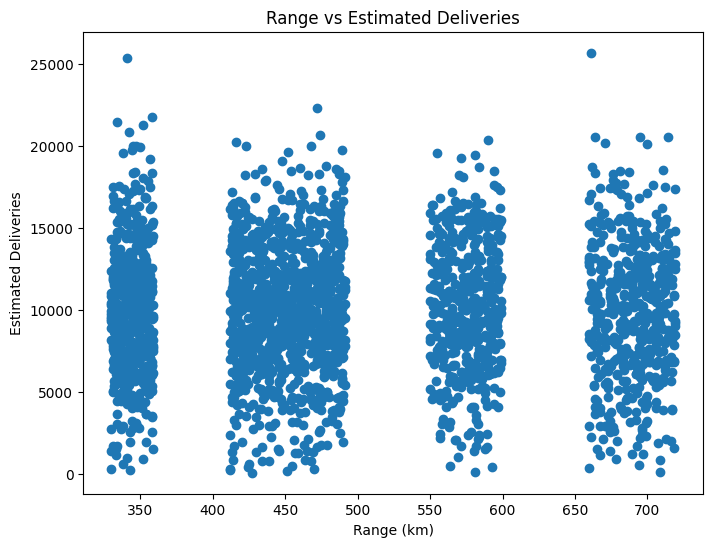

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(df["Range_km"], df["Estimated_Deliveries"])
plt.title("Range vs Estimated Deliveries")
plt.xlabel("Range (km)")
plt.ylabel("Estimated Deliveries")

plt.show()

In [22]:
yearly_stations = df.groupby("Year")["Charging_Stations"].mean()
yearly_stations.sort_values(ascending=False)

Year
2015    9269.012500
2023    9100.670833
2024    9060.212500
2019    9017.975000
2022    8972.075000
2016    8919.420833
2021    8909.716667
2020    8863.420833
2018    8750.075000
2025    8737.329167
2017    8653.562500
Name: Charging_Stations, dtype: float64

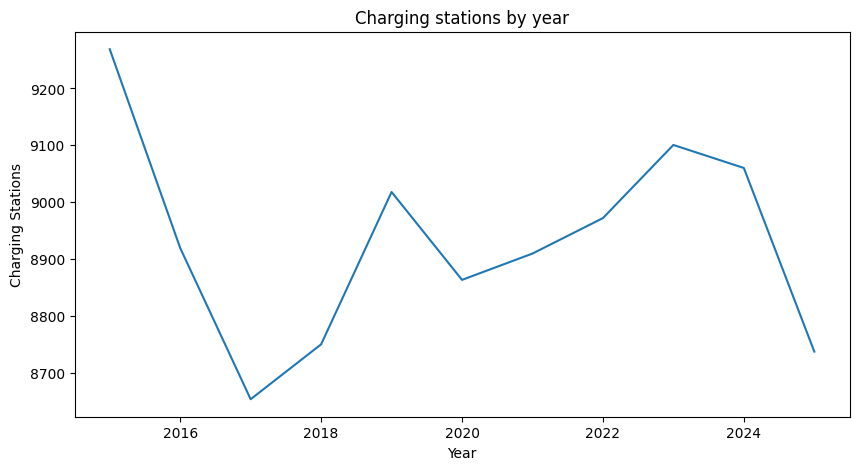

In [23]:
plt.figure(figsize=(10,5))

plt.plot(yearly_stations.index, yearly_stations.values)
plt.title("Charging stations by year")
plt.xlabel("Year")
plt.ylabel("Charging Stations")

plt.show()

# Insight

The number of charging stations changes over the years.

In [24]:
X = df[["Battery_Capacity_kWh", "Range_km", "Avg_Price_USD"]]

y = df["Estimated_Deliveries"]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [27]:
predictions = model.predict(X_test)


In [28]:
from sklearn.metrics import r2_score, mean_squared_error

score = r2_score(y_test, predictions)
MSE = mean_squared_error(y_test, predictions)
print(score, MSE)

0.000882625316574015 14893131.466540975


# Insight

A Linear Regression model was used to predict estimated deliveries using battery capacity, range, and price

# Conclusion

In this project, Tesla delivery and production data was analyzed using Python. Different graphs were used to understand trends across models, regions, years, battery capacity, and charging stations. A simple machine learning model was also used to predict estimated deliveries.